In [56]:
import sys
from pathlib import Path
import os

# Dynamically resolve the project root and add it to the system path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Standardized directories for notebook usage
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'

In [57]:
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error
from src.preprocessing import engineer_features, add_holidays, add_crisis_flags, apply_cyclical_encoding, add_lag_features
import warnings
warnings.filterwarnings('ignore')


# 1. Load Data and map Hebrew columns
df_future = pd.read_excel(os.path.join(DATA_DIR, 'OCC DJ DT june.xlsx'))

rename_map = {
    'מלון': 'Hotel',
    'תאריך הזמנה': 'Date',
    'חדרים למכירה': 'Total_Rooms',
    'חדרים תפוסים': 'Occupied_Rooms',
    'אחוז תפוסה': 'Occupancy_Rate',
    'אחוז ישראלים': 'Percentage_of_Israelis',
    'אחוז תיירים': 'Percentage_of_Tourists'
}

df_future = df_future.rename(columns=rename_map)
df_future['Hotel_ID'] = df_future['Hotel'].replace({'Dan Tel Aviv': 'DT', 'Dan Jerusalem': 'DJ', 'DJ': 'DJ'})
df_future['Date'] = pd.to_datetime(df_future['Date'])

# 2. Apply Preprocessing Pipeline
df_future = engineer_features(df_future)
df_future[['Event', 'is_chol_hamoed', 'is_holiday_eve']] = df_future['Date'].dt.date.apply(add_holidays)
df_future = add_crisis_flags(df_future)
df_future = apply_cyclical_encoding(df_future)
df_future = add_lag_features(df_future)

# CORRECTION 1 : On drop les NaNs générés par le shift sur les bonnes colonnes
df_test = df_future.dropna(subset=['Lag_7d', 'Rolling_Mean_14d']).copy()

# 3. Align Features for DT Inference
model_dt = joblib.load(os.path.join(MODELS_DIR, 'model_dt.pkl')) 
# On récupère l'empreinte exacte des colonnes d'entraînement
expected_features = model_dt.feature_names_in_

test_dt = df_test[df_test['Hotel_ID'] == 'DT'].copy()

if not test_dt.empty:
    # On transforme les catégories en colonnes (Dummies)
    X_test_dt = pd.get_dummies(test_dt, columns=['Event'], drop_first=True)
    
    X_test_dt = X_test_dt.reindex(columns=expected_features, fill_value=0)
    
    # On prédit et on évalue
    preds_dt = model_dt.predict(X_test_dt)
    mae_dt = mean_absolute_error(test_dt['Target_Rate'], preds_dt)
    
    print(f"Robustness Test - Dan Tel Aviv (June 2026) MAE: {mae_dt * 100:.2f}%")
else:
    print("Aucune donnée disponible pour le DT après nettoyage.")

AttributeError: 'Prophet' object has no attribute 'feature_names_in_'

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from src.preprocessing import load_data, engineer_features, add_holidays, add_crisis_flags, apply_cyclical_encoding, fill_missing_dates, add_lag_features, split_datasets
import joblib
import pandas as pd

print("--- Lancement du Test de Robustesse pour Dan Jérusalem ---")

# 1. Recharger l'historique pour calibrer le Scaler ET retrouver l'empreinte des colonnes
data_hist = load_data(os.path.join(DATA_DIR, 'Master.xlsx'))
data_hist = engineer_features(data_hist)
data_hist[['Event', 'is_chol_hamoed', 'is_holiday_eve']] = data_hist['Date'].dt.date.apply(add_holidays)
data_hist = add_crisis_flags(data_hist)
data_hist = apply_cyclical_encoding(data_hist)
data_hist = fill_missing_dates(data_hist)
data_hist = add_lag_features(data_hist)

train_pure, val_pure = split_datasets(data_hist)
full_dj_history = pd.concat([train_pure[train_pure['Hotel_ID'] == 'DJ'], val_pure[val_pure['Hotel_ID'] == 'DJ']])

# Les features de base
features_base = ['DayWeek', 'Is_Weekend', 'sin_doy', 'cos_doy', 'Event', 'is_chol_hamoed', 'is_holiday_eve', 'Lag_1d', 'Lag_7d', 'Rolling_Mean_7d', 'Rolling_Mean_14d']

# CORRECTION : Création des colonnes exactes depuis l'historique
X_history_dj = pd.get_dummies(full_dj_history[features_base], columns=['Event'], drop_first=True)
expected_features_dj = X_history_dj.columns 

# 2. Charger le modèle
model_dj = joblib.load(os.path.join(MODELS_DIR,'model_dj.pkl'))

# 3. Préparer les données de Juin 2026 (df_test a été généré dans la cellule précédente de ton notebook)
test_dj = df_test[df_test['Hotel_ID'] == 'DJ'].copy()

if not test_dj.empty:
    X_test_dj = pd.get_dummies(test_dj[features_base], columns=['Event'], drop_first=True)
    
    # On aligne le test sur les colonnes de l'historique
    X_test_dj = X_test_dj.reindex(columns=expected_features_dj, fill_value=0)
    
    # 4. Appliquer le Scaling (Le scaler apprend du passé et transforme le futur)
    scaler = StandardScaler()
    X_history_scaled = scaler.fit_transform(X_history_dj)
    X_test_dj_scaled = scaler.transform(X_test_dj)
    
    # 5. Prédiction et Évaluation
    preds_dj = model_dj.predict(X_test_dj_scaled)
    mae_dj = mean_absolute_error(test_dj['Target_Rate'], preds_dj)
    
    print(f"Robustness Test - Dan Jerusalem (June 2026) MAE: {mae_dj * 100:.2f}%")
else:
    print("Aucune donnée disponible pour le DJ après nettoyage.")

--- Lancement du Test de Robustesse pour Dan Jérusalem ---
Robustness Test - Dan Jerusalem (June 2026) MAE: 17.21%


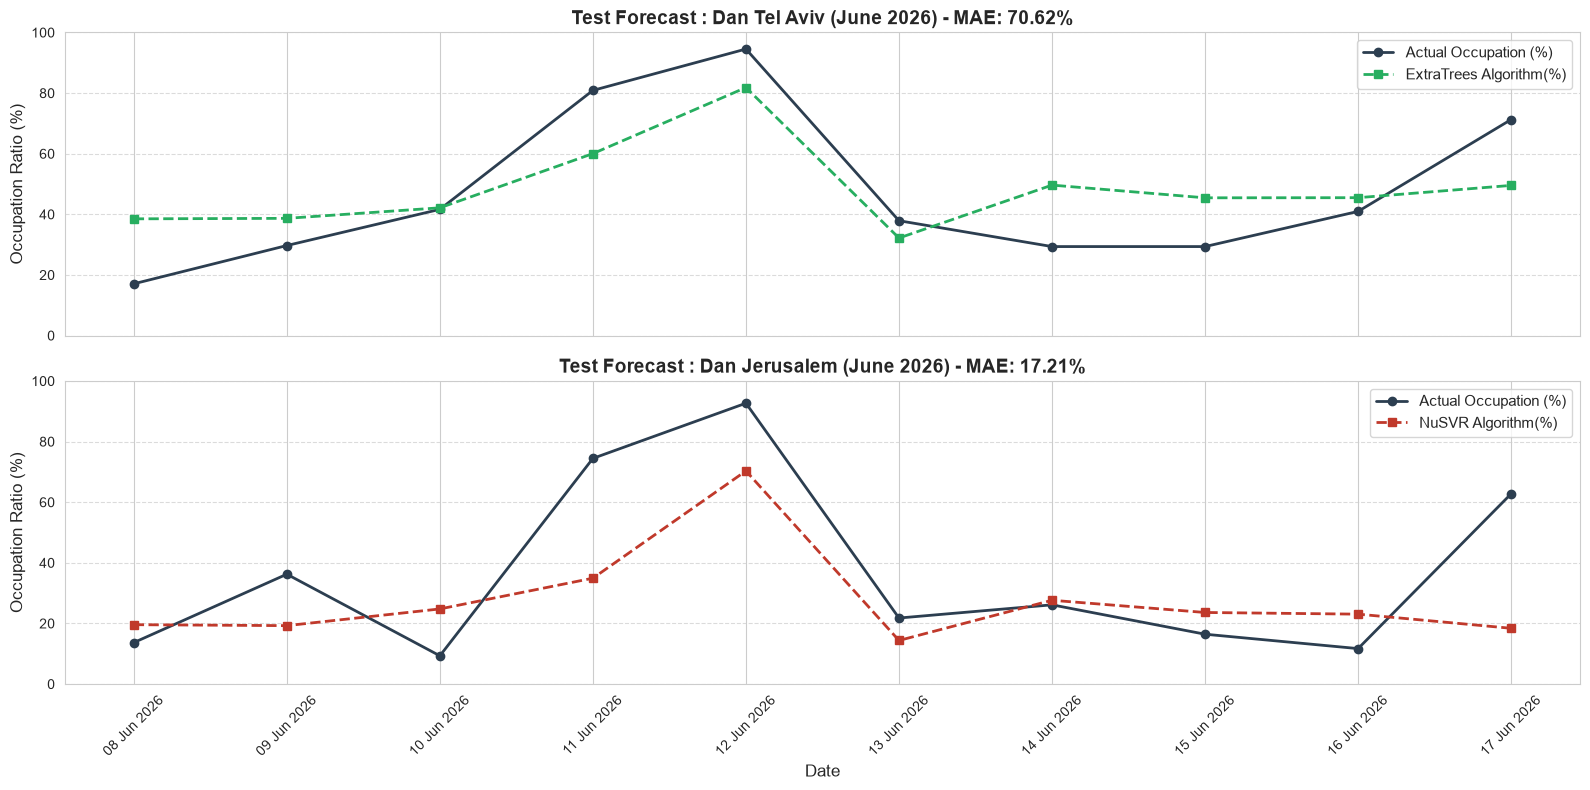

In [59]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Création de la figure avec deux graphiques superposés
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# 1. Graphique pour Dan Tel Aviv
axes[0].plot(test_dt['Date'], test_dt['Target_Rate'] * 100, label='Actual Occupation (%)', color='#2c3e50', linewidth=2, marker='o')
axes[0].plot(test_dt['Date'], preds_dt * 100, label='ExtraTrees Algorithm(%)', color='#27ae60', linewidth=2, linestyle='--', marker='s')
axes[0].set_title(f'Test Forecast : Dan Tel Aviv (June 2026) - MAE: {mae_dt*100:.2f}%', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Occupation Ratio (%)', fontsize=12)
axes[0].legend(loc='upper right', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, 100)

# 2. Graphique pour Dan Jérusalem
axes[1].plot(test_dj['Date'], test_dj['Target_Rate'] * 100, label='Actual Occupation (%)', color='#2c3e50', linewidth=2, marker='o')
axes[1].plot(test_dj['Date'], preds_dj * 100, label='NuSVR Algorithm(%)', color='#c0392b', linewidth=2, linestyle='--', marker='s')
axes[1].set_title(f'Test Forecast : Dan Jerusalem (June 2026) - MAE: {mae_dj*100:.2f}%', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Occupation Ratio (%)', fontsize=12)
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, 100)

# Formatage de l'axe X pour afficher les jours proprement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig('robustness_june_2026.png', dpi=300)
plt.show()

In [60]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler

print("--- Lancement du Test J+7 (Approche Récursive) ---")
print("Date de départ : 10 Juin 2026 --> Cible : 17 Juin 2026\n")

# 1. Chargement des modèles et des empreintes de colonnes
# model_dt = joblib.load('model_dt.pkl')
# model_dj = joblib.load('model_dj.pkl')
expected_features_dt = model_dt.feature_names_in_

# 2. Préparation du Scaler pour DJ (Entraîné sur l'historique)
train_pure, val_pure = split_datasets(data_hist)
full_dj_history = pd.concat([train_pure[train_pure['Hotel_ID'] == 'DJ'], val_pure[val_pure['Hotel_ID'] == 'DJ']])
features_base = ['DayWeek', 'Is_Weekend', 'sin_doy', 'cos_doy', 'Event', 'is_chol_hamoed', 'is_holiday_eve', 'Lag_1d', 'Lag_7d', 'Rolling_Mean_7d', 'Rolling_Mean_14d']
X_history_dj = pd.get_dummies(full_dj_history[features_base], columns=['Event'], drop_first=True).reindex(columns=expected_features_dj, fill_value=0)
scaler_dj = StandardScaler().fit(X_history_dj)

# 3. Fonction d'Inférence Récursive
def recursive_forecast_7d(start_date_str, hotel_id, model, expected_features, df_hist, df_fut, scaler=None):
    start_date = pd.to_datetime(start_date_str)
    
    # On rassemble l'historique et le mois de juin JUSQU'AU jour de départ (10 Juin inclus)
    df_combined = pd.concat([df_hist[df_hist['Hotel_ID']==hotel_id], df_fut[df_fut['Hotel_ID']==hotel_id]])
    df_combined = df_combined.drop_duplicates(subset=['Date']).sort_values('Date')
    
    # On extrait la "vraie" mémoire : les 14 derniers jours d'occupation
    past_rates = df_combined[df_combined['Date'] <= start_date]['Target_Rate'].tolist()
    
    print(f"[{hotel_id}] Mémoire initiale (Target Rate du {start_date_str}) : {past_rates[-1]*100:.1f}%")
    
    current_date = start_date
    predictions = []
    
    # Boucle de 7 jours (J+1 à J+7)
    for i in range(1, 8):
        current_date += pd.Timedelta(days=1)
        
        # On récupère le calendrier du jour futur (Saisons, Fêtes)
        row = df_fut[(df_fut['Date'] == current_date) & (df_fut['Hotel_ID'] == hotel_id)].copy()
        if row.empty: return None
            
        # CALCUL DYNAMIQUE DES LAGS (basé sur nos prédictions précédentes)
        row['Lag_1d'] = past_rates[-1]
        row['Lag_7d'] = past_rates[-7]
        row['Rolling_Mean_7d'] = np.mean(past_rates[-7:])
        row['Rolling_Mean_14d'] = np.mean(past_rates[-14:])
        
        # Encodage
        X_infer = pd.get_dummies(row[features_base], columns=['Event'], drop_first=True)
        X_infer = X_infer.reindex(columns=expected_features, fill_value=0)
        
        if scaler:
            X_infer = scaler.transform(X_infer)
            
        # Prédiction du jour i
        pred = model.predict(X_infer)[0]
        pred = np.clip(pred, 0.0, 1.0)
        
        # On ajoute cette prédiction à notre mémoire pour le tour de boucle suivant !
        past_rates.append(pred)
        predictions.append(pred)
        print(f"   -> J+{i} ({current_date.strftime('%Y-%m-%d')}) Prédiction : {pred*100:.2f}%")
        
    return predictions[-1] # On retourne la prédiction J+7

# 4. Exécution du test pour le 10 Juin 2026
target_date_test = '2026-06-17'

# ----- DAN TEL AVIV -----
print("\n--- HOTEL : DAN TEL AVIV (ExtraTrees) ---")
pred_7d_dt = recursive_forecast_7d('2026-06-10', 'DT', model_dt, expected_features_dt, data_hist, df_future)
actual_dt = df_future[(df_future['Date'] == target_date_test) & (df_future['Hotel_ID'] == 'DT')]['Target_Rate'].values[0]
print(f"\n=> RÉSULTAT J+7 pour le {target_date_test} :")
print(f"   Prédiction Récursive : {pred_7d_dt*100:.2f}%")
print(f"   Occupation Réelle    : {actual_dt*100:.2f}%")
print(f"   Erreur Absolue       : {abs(pred_7d_dt - actual_dt)*100:.2f} points")

# ----- DAN JÉRUSALEM -----
print("\n--- HOTEL : DAN JÉRUSALEM (NuSVR) ---")
pred_7d_dj = recursive_forecast_7d('2026-06-10', 'DJ', model_dj, expected_features_dj, data_hist, df_future, scaler=scaler_dj)
actual_dj = df_future[(df_future['Date'] == target_date_test) & (df_future['Hotel_ID'] == 'DJ')]['Target_Rate'].values[0]
print(f"\n=> RÉSULTAT J+7 pour le {target_date_test} :")
print(f"   Prédiction Récursive : {pred_7d_dj*100:.2f}%")
print(f"   Occupation Réelle    : {actual_dj*100:.2f}%")
print(f"   Erreur Absolue       : {abs(pred_7d_dj - actual_dj)*100:.2f} points")

--- Lancement du Test J+7 (Approche Récursive) ---
Date de départ : 10 Juin 2026 --> Cible : 17 Juin 2026



AttributeError: 'Prophet' object has no attribute 'feature_names_in_'

In [ ]:
df_future = pd.read_excel(os.path.join(DATA_DIR, 'OCC DJ DT june.xlsx'))

In [ ]:
df_future.columns

Index(['מלון', 'תאריך הזמנה', 'חדרים למכירה', 'חדרים תפוסים', 'אחוז תפוסה',
       'ADR Actual Net', 'ADR Gross Actual', 'RevPAR', 'אחוז ישראלים',
       'אחוז תיירים', 'DayName'],
      dtype='object')

In [ ]:
df_future[['מלון', 'תאריך הזמנה', 'חדרים למכירה', 'חדרים תפוסים', 'אחוז תפוסה', 'DayName']]

,מלון,תאריך הזמנה,חדרים למכירה,חדרים תפוסים,אחוז תפוסה,DayName
0,Dan Jerusalem,2026-06-01,505,21.00,0.041584,Monday
1,Dan Jerusalem,2026-06-02,505,14.00,0.027723,Tuesday
2,Dan Jerusalem,2026-06-03,505,10.00,0.019802,Wednesday
3,Dan Jerusalem,2026-06-04,505,422.00,0.835644,Thursday
4,Dan Jerusalem,2026-06-05,505,480.00,0.950495,Friday
5,Dan Jerusalem,2026-06-06,505,3.00,0.005941,Saturday
6,Dan Jerusalem,2026-06-07,505,63.00,0.124752,Sunday
7,Dan Jerusalem,2026-06-08,505,69.00,0.136634,Monday
8,Dan Jerusalem,2026-06-09,505,182.99,0.362356,Tuesday
9,Dan Jerusalem,2026-06-10,505,47.00,0.093069,Wednesday


In [ ]:
df_future.head(10)

,מלון,תאריך הזמנה,חדרים למכירה,חדרים תפוסים,אחוז תפוסה,ADR Actual Net,ADR Gross Actual,RevPAR,אחוז ישראלים,אחוז תיירים
0,Dan Jerusalem,2026-06-01,505,21.00,0.041584,868.739048,1000.467619,36.125782,0.904762,0.095238
1,Dan Jerusalem,2026-06-02,505,14.00,0.027723,-78.402857,-185.481429,-2.173545,0.928571,0.071429
2,Dan Jerusalem,2026-06-03,505,10.00,0.019802,469.167000,528.613000,9.290436,0.900000,0.100000
3,Dan Jerusalem,2026-06-04,505,422.00,0.835644,806.582607,961.868863,674.015564,0.997630,0.000000
4,Dan Jerusalem,2026-06-05,505,480.00,0.950495,1006.861500,1436.711812,957.016871,0.997917,0.000000
5,Dan Jerusalem,2026-06-06,505,3.00,0.005941,332.096667,601.696667,1.972851,1.000000,0.000000
6,Dan Jerusalem,2026-06-07,505,63.00,0.124752,754.289841,956.046984,94.099525,0.920635,0.031746
7,Dan Jerusalem,2026-06-08,505,69.00,0.136634,737.118696,922.088261,100.715228,0.927536,0.028986
8,Dan Jerusalem,2026-06-09,505,182.99,0.362356,711.199301,889.288158,257.707644,0.983606,0.010930
9,Dan Jerusalem,2026-06-10,505,47.00,0.093069,-22.037234,103.188723,-2.050990,0.872340,0.063830


In [ ]:
df_future['אחוז תפוסה'][:14].to_list()

[0.041584158415841586,
 0.027722772277227723,
 0.019801980198019802,
 0.8356435643564356,
 0.9504950495049505,
 0.005940594059405941,
 0.12475247524752475,
 0.13663366336633664,
 0.36235643564356446,
 0.09306930693069307,
 0.7445346534653465,
 0.9266336633663369,
 0.21772277227722767,
 0.26128712871287124]

In [ ]:
df_future['DayName'] = df_future['תאריך הזמנה'].dt.day_name()

In [ ]:
df_future.head(10)

,מלון,תאריך הזמנה,חדרים למכירה,חדרים תפוסים,אחוז תפוסה,ADR Actual Net,ADR Gross Actual,RevPAR,אחוז ישראלים,אחוז תיירים,DayName
0,Dan Jerusalem,2026-06-01,505,21.00,0.041584,868.739048,1000.467619,36.125782,0.904762,0.095238,Monday
1,Dan Jerusalem,2026-06-02,505,14.00,0.027723,-78.402857,-185.481429,-2.173545,0.928571,0.071429,Tuesday
2,Dan Jerusalem,2026-06-03,505,10.00,0.019802,469.167000,528.613000,9.290436,0.900000,0.100000,Wednesday
3,Dan Jerusalem,2026-06-04,505,422.00,0.835644,806.582607,961.868863,674.015564,0.997630,0.000000,Thursday
4,Dan Jerusalem,2026-06-05,505,480.00,0.950495,1006.861500,1436.711812,957.016871,0.997917,0.000000,Friday
5,Dan Jerusalem,2026-06-06,505,3.00,0.005941,332.096667,601.696667,1.972851,1.000000,0.000000,Saturday
6,Dan Jerusalem,2026-06-07,505,63.00,0.124752,754.289841,956.046984,94.099525,0.920635,0.031746,Sunday
7,Dan Jerusalem,2026-06-08,505,69.00,0.136634,737.118696,922.088261,100.715228,0.927536,0.028986,Monday
8,Dan Jerusalem,2026-06-09,505,182.99,0.362356,711.199301,889.288158,257.707644,0.983606,0.010930,Tuesday
9,Dan Jerusalem,2026-06-10,505,47.00,0.093069,-22.037234,103.188723,-2.050990,0.872340,0.063830,Wednesday


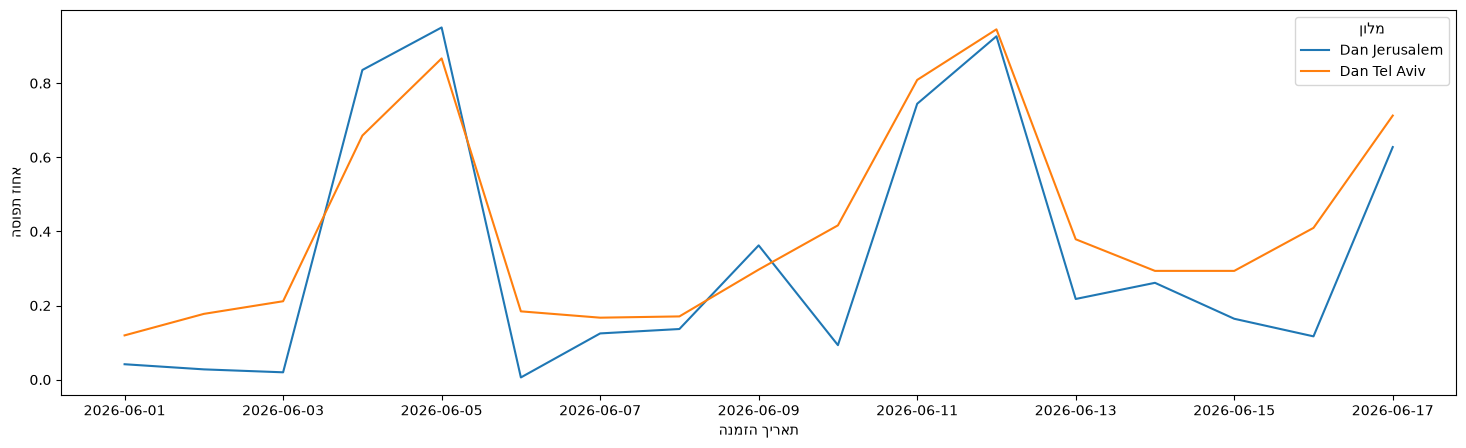

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (18, 5))
sns.lineplot(data = df_future, x = 'תאריך הזמנה', y = 'אחוז תפוסה', hue = 'מלון')
plt.show()

In [ ]:
data_hist = load_data(os.path.join(DATA_DIR, 'Master.xlsx'))
data_hist.tail()

,Date,Year,Month,Day_Of_Week,Is_Weekend,Is_Holiday,Hotel_ID,Occupied_Rooms,Total_Rooms,Occupancy_Rate,...,Total_Reception_Employees,Total_Room_Services_Hours,Total_Room_Services_Employees,Total_Security_Hours,Total_Security_Employees,Total_Waiters_Hours,Total_Waiters_Employees,Percentage_of_Israelis,Percentage_of_Tourists,Key
5839,2025-12-29,2025,12,Monday,0,0,DT,121.98,293.0,0.416314,...,6,0.00,0,46.35,6,184.41,23,0.229546,0.713068,29/12/2025DT
5840,2025-12-30,2025,12,Tuesday,0,0,DJ,41.00,505.0,0.081188,...,5,0.00,0,58.16,8,52.70,7,0.804878,0.170732,30/12/2025DJ
5841,2025-12-30,2025,12,Tuesday,0,0,DT,120.98,293.0,0.412901,...,8,7.98,1,42.78,5,190.31,24,0.231443,0.735493,30/12/2025DT
5842,2025-12-31,2025,12,Wednesday,0,0,DJ,214.97,505.0,0.425683,...,6,0.00,0,65.46,9,208.32,22,0.962786,0.023259,31/12/2025DJ
5843,2025-12-31,2025,12,Wednesday,0,0,DT,135.98,293.0,0.464096,...,6,0.00,0,42.10,5,175.27,20,0.198559,0.727901,31/12/2025DT


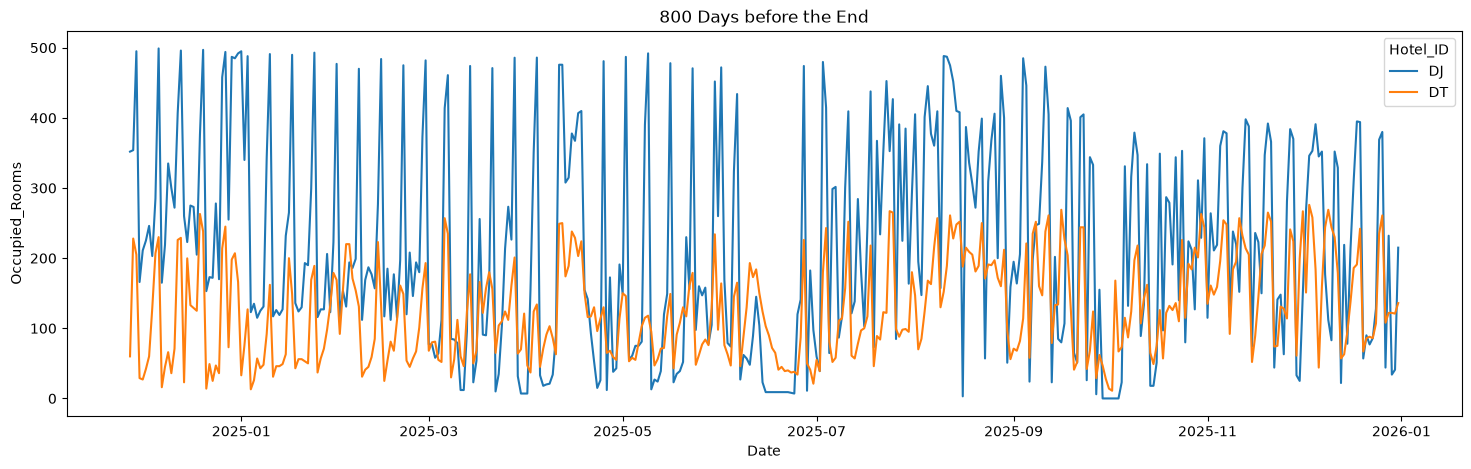

In [ ]:
data_hist = load_data(os.path.join(DATA_DIR, 'Master.xlsx'))
data_test = data_hist.tail(800)

plt.figure(figsize = (18, 5))
sns.lineplot(data = data_test, x = 'Date', y = 'Occupied_Rooms', hue = 'Hotel_ID')
plt.title('800 Days before the End')
plt.show()

=== SIMULATION DE PRODUCTION (Prévision à J+7 à l'aveugle) ===
Génération des prévisions pour la semaine suivant le 2025-06-07...
MAE de la semaine simulée : 14.66 points d'erreur



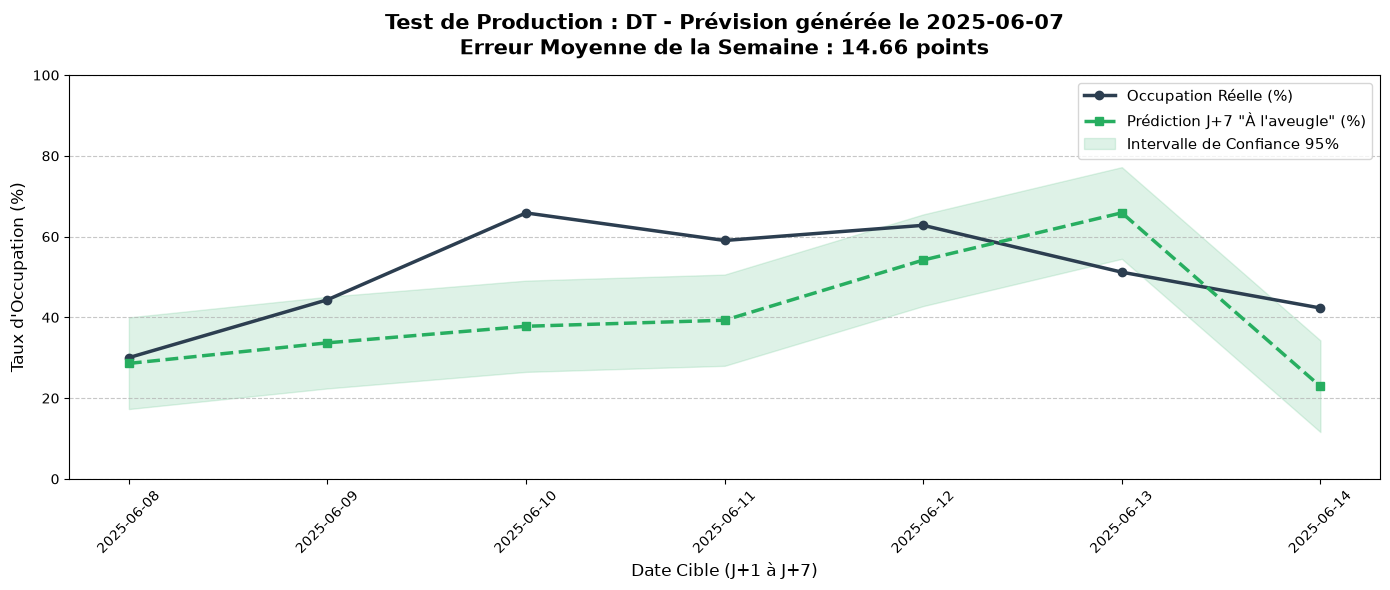

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration des chemins
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import de notre VRAIE fonction de production (qui utilise les 7 sous-modèles figés)
from src.preprocessing import load_data, engineer_features, fill_missing_dates
from src.inference import predict_weekly_occupancy

DATA_DIR = PROJECT_ROOT / 'data'

print("=== SIMULATION DE PRODUCTION (Prévision à J+7 à l'aveugle) ===")

# 2. Chargement de l'historique brut
df = load_data(DATA_DIR / 'Master.xlsx')
df = engineer_features(df)
df = fill_missing_dates(df) # Garantie d'un calendrier continu
df = df.sort_values(by=['Hotel_ID', 'Date']).reset_index(drop=True)


HOTEL_ID = 'DT'             # 'DT' (Tel Aviv) ou 'DJ' (Jérusalem)
START_DATE = '2025-06-07'   # La date où le manager ouvre son logiciel (Un Dimanche)
# ==========================================

# 3. Isolement de la "Mémoire Opérationnelle" (Les 14 jours AVANT le départ)
hotel_df = df[df['Hotel_ID'] == HOTEL_ID].copy()
past_data = hotel_df[hotel_df['Date'] <= START_DATE].tail(14)

if len(past_data) < 14:
    print("Erreur : Pas assez d'historique avant cette date.")
    sys.exit()

past_14_rates = past_data['Target_Rate'].tolist()

print(f"Génération des prévisions pour la semaine suivant le {START_DATE}...")
forecast_results = predict_weekly_occupancy(START_DATE, HOTEL_ID, past_14_rates)

future_dates = [res['Date'] for res in forecast_results]
actual_data = hotel_df[hotel_df['Date'].isin(pd.to_datetime(future_dates))][['Date', 'Target_Rate']]
actual_data['Date'] = actual_data['Date'].dt.strftime('%Y-%m-%d')
df_plot = pd.DataFrame(forecast_results)
df_plot = pd.merge(df_plot, actual_data, on='Date', how='left')
df_plot['Target_Rate'] = df_plot['Target_Rate'] * 100 # Mettre en pourcentage

mae_week = abs(df_plot['Forecast'] - df_plot['Target_Rate']).mean()
print(f"MAE de la semaine simulée : {mae_week:.2f} points d'erreur\n")

plt.figure(figsize=(14, 6))
plt.plot(df_plot['Date'], df_plot['Target_Rate'], label='Occupation Réelle (%)', color='#2c3e50', marker='o', linewidth=2.5)
plt.plot(df_plot['Date'], df_plot['Forecast'], label='Prédiction J+7 "À l\'aveugle" (%)', color='#27ae60', marker='s', linestyle='--', linewidth=2.5)

# Confidence Interval
plt.fill_between(df_plot['Date'], df_plot['Lower_95'], df_plot['Upper_95'], color='#27ae60', alpha=0.15, label='Intervalle de Confiance 95%')

plt.title(f'Test de Production : {HOTEL_ID} - Prévision générée le {START_DATE}\nErreur Moyenne de la Semaine : {mae_week:.2f} points', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Date Cible (J+1 à J+7)', fontsize=12)
plt.ylabel('Taux d\'Occupation (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# --- 1. Résolution des chemins ---
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import load_data, engineer_features, fill_missing_dates
from src.inference import predict_weekly_occupancy

DATA_DIR = PROJECT_ROOT / 'data'

print("=== BACKTEST MASSIF : SIMULATION DE PRODUCTION (S1 2025) ===\n")

# --- 2. Chargement de l'historique brut ---
df = load_data(DATA_DIR / 'Master.xlsx')
df = engineer_features(df)
df = fill_missing_dates(df)
df = df.sort_values(by=['Hotel_ID', 'Date']).reset_index(drop=True)

# Période de test (Les 6 premiers mois de 2025)
START_TEST_DATE = '2025-01-01'
END_TEST_DATE = '2025-06-30'
test_dates = pd.date_range(start=START_TEST_DATE, end=END_TEST_DATE)

def run_production_simulation(hotel_id):
    hotel_df = df[df['Hotel_ID'] == hotel_id].copy()
    weekly_errors = []
    
    print(f"Lancement de la simulation pour {hotel_id}...")
    
    for current_date in test_dates:
        # 1. Isoler strictement le passé (14 jours)
        past_data = hotel_df[hotel_df['Date'] <= current_date].tail(14)
        if len(past_data) < 14:
            continue
            
        past_14_rates = past_data['Target_Rate'].tolist()
        
        # 2. Prédire les 7 prochains jours "à l'aveugle"
        try:
            forecast = predict_weekly_occupancy(current_date.strftime('%Y-%m-%d'), hotel_id, past_14_rates)
        except Exception:
            continue
            
        # 3. Récupérer la réalité des 7 jours ciblés
        future_dates = [pd.to_datetime(res['Date']) for res in forecast]
        actual_data = hotel_df[hotel_df['Date'].isin(future_dates)]['Target_Rate'].tolist()
        
        # 4. Calculer l'erreur si nous avons bien 7 jours réels pour comparer
        if len(actual_data) == 7:
            pred_data = [res['Forecast'] / 100.0 for res in forecast] # Remise en taux décimal
            mae_week = np.mean(np.abs(np.array(pred_data) - np.array(actual_data)))
            weekly_errors.append(mae_week)
            
    # Calcul de la MAE finale (Moyenne de toutes les moyennes hebdomadaires)
    global_mae = np.mean(weekly_errors) * 100
    print(f"-> 🏆 {hotel_id} : MAE Opérationnelle Globale sur {len(weekly_errors)} semaines de test = {global_mae:.2f} points d'erreur\n")

# --- 3. Exécution ---
run_production_simulation('DT')
run_production_simulation('DJ')

=== BACKTEST MASSIF : SIMULATION DE PRODUCTION (S1 2025) ===

Lancement de la simulation pour DT...
-> 🏆 DT : MAE Opérationnelle Globale sur 181 semaines de test = 3.77 points d'erreur

Lancement de la simulation pour DJ...
-> 🏆 DJ : MAE Opérationnelle Globale sur 181 semaines de test = 14.91 points d'erreur



=== ACTUAL VS 7-DAY BLIND FORECAST (FULL YEAR 2025 - CRISIS EXCLUDED) ===
Calcul de la courbe J+7 pour DT...
Calcul de la courbe J+7 pour DJ...


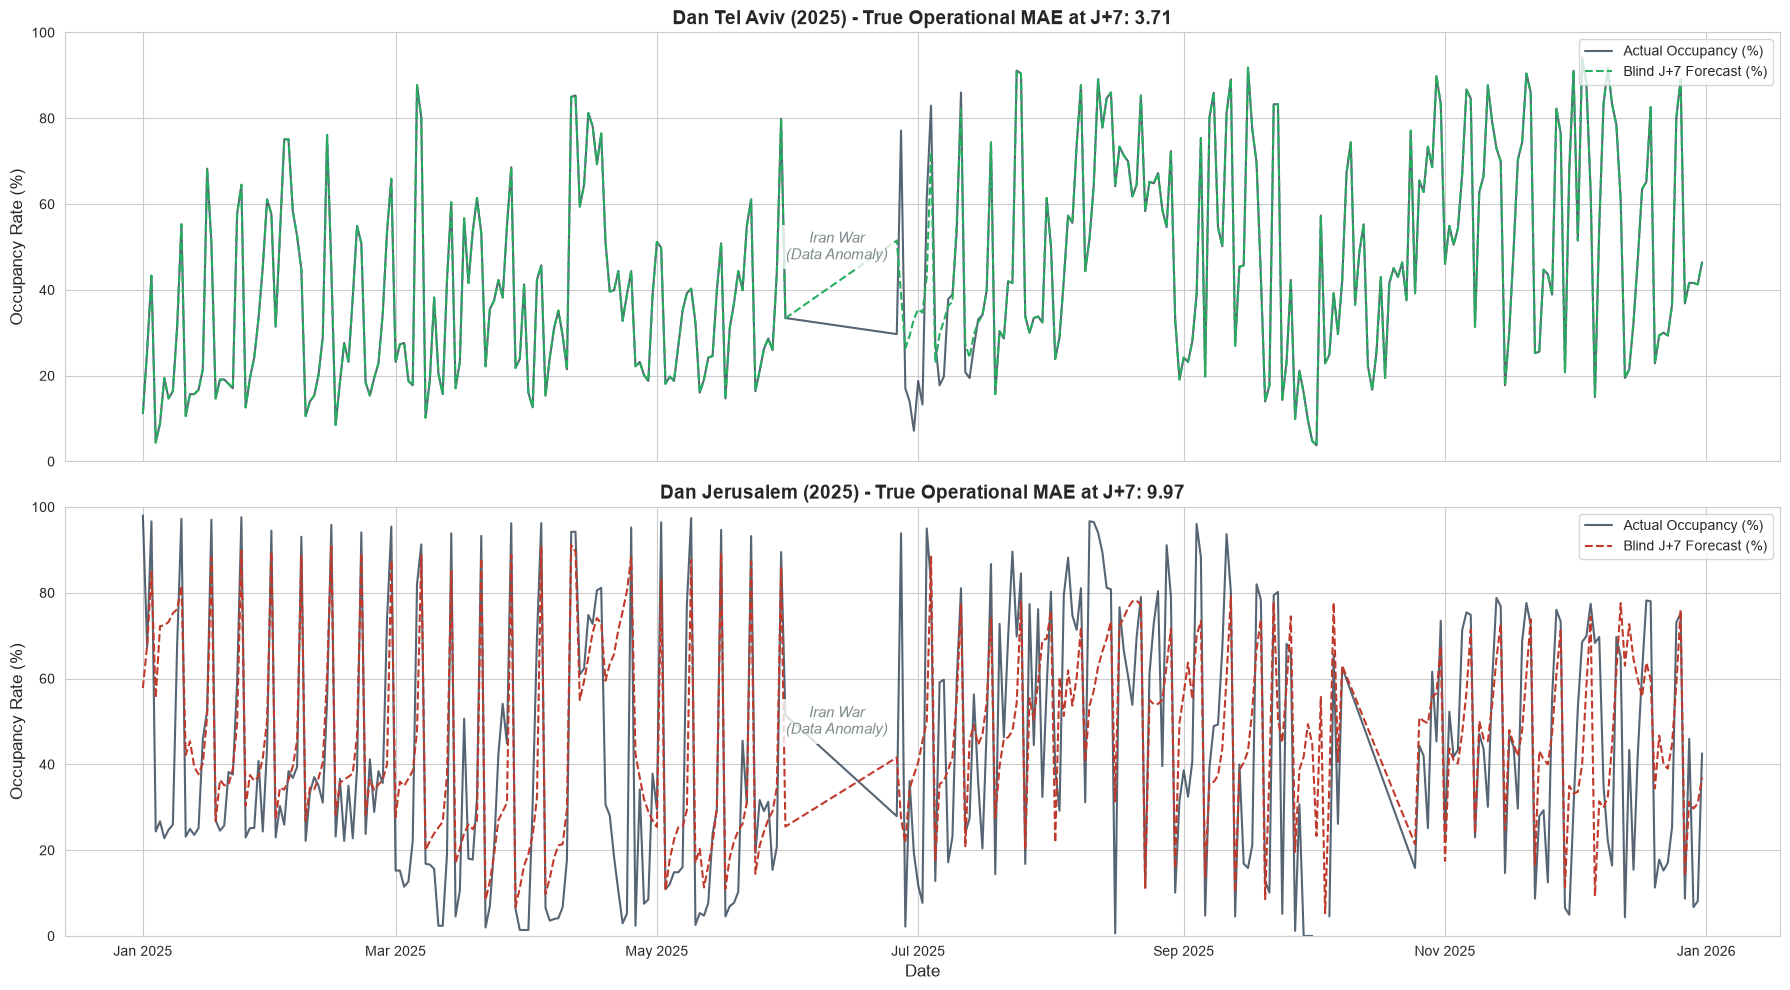

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# --- 1. Résolution des chemins ---
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import load_data, engineer_features, fill_missing_dates
from src.inference import predict_weekly_occupancy

DATA_DIR = PROJECT_ROOT / 'data'

print("=== ACTUAL VS 7-DAY BLIND FORECAST (FULL YEAR 2025 - CRISIS EXCLUDED) ===")

# --- 2. Chargement de la donnée ---
df = load_data(DATA_DIR / 'Master.xlsx')
df = engineer_features(df)
df = fill_missing_dates(df)
df = df.sort_values(by=['Hotel_ID', 'Date']).reset_index(drop=True)

simulation_dates = pd.date_range(start='2024-12-25', end='2025-12-24')

def get_blind_forecast_curve(hotel_id):
    hotel_df = df[df['Hotel_ID'] == hotel_id].copy()
    print(f"Calcul de la courbe J+7 pour {hotel_id}...")
    
    results = []
    
    for current_date in simulation_dates:
        target_date = current_date + pd.DateOffset(days=7)
        
        # --- FILTRE DE CRISE (Le "Fill Léger") ---
        # On exclut strictement la période géopolitique pour ne pas fausser la MAE opérationnelle
        if '2025-06-01' <= target_date.strftime('%Y-%m-%d') <= '2025-06-25':
            continue
            
        past_data = hotel_df[hotel_df['Date'] <= current_date].tail(14)
        if len(past_data) < 14:
            continue
            
        past_14_rates = past_data['Target_Rate'].tolist()
        
        try:
            forecast = predict_weekly_occupancy(current_date.strftime('%Y-%m-%d'), hotel_id, past_14_rates)
        except Exception:
            continue
            
        j7_prediction = forecast[-1]
        
        actual_row = hotel_df[hotel_df['Date'] == target_date]
        if not actual_row.empty:
            actual_val = actual_row['Target_Rate'].values[0] * 100
            
            results.append({
                'Date': target_date,
                'Actual_Occupancy': actual_val,
                'Predicted_J7': j7_prediction['Forecast']
            })
            
    return pd.DataFrame(results)

# --- 3. Exécution ---
df_dt = get_blind_forecast_curve('DT')
df_dj = get_blind_forecast_curve('DJ') 


# Calcul des erreurs moyennes opérationnelles "propres"
mae_dt = np.mean(np.abs(df_dt['Actual_Occupancy'] - df_dt['Predicted_J7'])) 
mae_dj = np.mean(np.abs(df_dj['Actual_Occupancy'] - df_dj['Predicted_J7'])) 

# --- 4. Affichage Graphique (2 Subplots) ---
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
sns.set_style("whitegrid")

# Graphique Dan Tel Aviv
axes[0].plot(df_dt['Date'], df_dt['Actual_Occupancy'], label='Actual Occupancy (%)', color='#2c3e50', linewidth=1.5, alpha=0.8)
axes[0].plot(df_dt['Date'], df_dt['Predicted_J7'], label='Blind J+7 Forecast (%)', color='#27ae60', linestyle='--', linewidth=1.5)
axes[0].set_title(f'Dan Tel Aviv (2025) - True Operational MAE at J+7: {mae_dt:.2f}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Occupancy Rate (%)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, 100)

# Annotation visuelle de la crise (DT)
axes[0].text(pd.to_datetime('2025-06-12'), 50, 'Iran War\n(Data Anomaly)', 
             ha='center', va='center', color='#7f8c8d', style='italic', fontsize=11,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Graphique Dan Jerusalem
axes[1].plot(df_dj['Date'], df_dj['Actual_Occupancy'], label='Actual Occupancy (%)', color='#2c3e50', linewidth=1.5, alpha=0.8)
axes[1].plot(df_dj['Date'], df_dj['Predicted_J7'], label='Blind J+7 Forecast (%)', color='#c0392b', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Dan Jerusalem (2025) - True Operational MAE at J+7: {mae_dj:.2f}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Occupancy Rate (%)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].set_ylim(0, 100)

# Annotation visuelle de la crise (DJ)
axes[1].text(pd.to_datetime('2025-06-12'), 50, 'Iran War\n(Data Anomaly)', 
             ha='center', va='center', color='#7f8c8d', style='italic', fontsize=11,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Formatage des dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=0)

plt.tight_layout()
#plt.savefig('Final_Actual_vs_J7_Forecast_Clean.png', dpi=300)
plt.show()